In [1]:
#######  V2 #############


import torch
import torch.nn as nn
import torch.nn.functional as F

from groupy.gconv.pytorch_gconv.splitgconv2d import P4ConvZ2, P4ConvP4
from groupy.gconv.pytorch_gconv import P4MConvZ2, P4MConvP4M
from groupy.gconv.pytorch_gconv.pooling import plane_group_spatial_max_pooling

class NNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(NNet, self).__init__()
        

        self.conv1 = P4MConvZ2(in_channels, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = P4MConvP4M(32, 32, kernel_size=3, stride=1, padding=1)

        self.conv3 = P4MConvP4M(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv4 = P4MConvP4M(64, 128, kernel_size=3, stride=1, padding=1)

        self.conv5 = P4MConvP4M(128, 64, kernel_size=3, padding=1)
        self.conv6 = P4MConvP4M(64, 32, kernel_size=3, padding=1)

#         self.conv3 = P4MConvP4M(48, 96, kernel_size=3, stride=1, padding=1)
#         self.conv4 = P4MConvP4M(96, 192, kernel_size=3, stride=1, padding=1)

#         self.conv5 = P4MConvP4M(192, 96, kernel_size=3, padding=1)
#         self.conv6 = P4MConvP4M(96, 48, kernel_size=3, padding=1)
        self.convt = nn.ConvTranspose2d(32*8, out_channels, kernel_size=2, stride=2, output_padding=0)


    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = plane_group_spatial_max_pooling(x, 2, 2)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        xs = x.size()
        x = x.view(xs[0], xs[1] * xs[2], xs[3], xs[4])
#         x = F.avg_pool2d(x, 2, 2)
        x = self.convt(x)

        return x

In [2]:
model = NNet(1, 1).cuda()
# model = ResNet18()

In [3]:
from torchsummary import summary
summary(model, (1, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
         P4MConvZ2-1      [-1, 32, 8, 128, 128]             320
        P4MConvP4M-2      [-1, 32, 8, 128, 128]          73,760
        P4MConvP4M-3        [-1, 64, 8, 64, 64]         147,520
        P4MConvP4M-4       [-1, 128, 8, 64, 64]         589,952
        P4MConvP4M-5        [-1, 64, 8, 64, 64]         589,888
        P4MConvP4M-6        [-1, 32, 8, 64, 64]         147,488
   ConvTranspose2d-7          [-1, 1, 128, 128]           1,025
Total params: 1,549,953
Trainable params: 1,549,953
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.06
Forward/backward pass size (MB): 136.12
Params size (MB): 5.91
Estimated Total Size (MB): 142.10
----------------------------------------------------------------


In [4]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


class ERDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = os.listdir(root_dir)

    def __len__(self):
        return sum(len(os.listdir(os.path.join(self.root_dir, cls, 'images'))) for cls in self.classes)

    def __getitem__(self, idx):
        current_class_idx = 0
        while idx >= len(os.listdir(os.path.join(self.root_dir, self.classes[current_class_idx], 'images'))):
            idx -= len(os.listdir(os.path.join(self.root_dir, self.classes[current_class_idx], 'images')))
            current_class_idx += 1

        current_class = self.classes[current_class_idx]
        img_folder = os.path.join(self.root_dir, current_class, 'images')
        mask_folder = os.path.join(self.root_dir, current_class, 'masks')

        img_name = os.listdir(img_folder)[idx]
        img_path = os.path.join(img_folder, img_name)
        mask_name = os.path.splitext(img_name)[0] + '_mask.png'  # Assuming mask files have the same name as images with '_mask' appended
        mask_path = os.path.join(mask_folder, mask_name)

        image = Image.open(img_path)#.convert("RGB")
        mask = Image.open(mask_path)#.convert("L")  # Convert to grayscale mask

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask

/localhome/asa420/anaconda3/envs/as3/lib/python3.7/site-packages/torchvision/io/image.py:11: UserWarning: Failed to load image Python extension: /local-scratch/localhome/asa420/anaconda3/envs/as3/lib/python3.7/site-packages/torchvision/image.so: undefined symbol: _ZNK3c1010TensorImpl36is_contiguous_nondefault_policy_implENS_12MemoryFormatE
  warn(f"Failed to load image Python extension: {e}")


In [8]:
import torch

class VectorAdam(torch.optim.Optimizer):
    def __init__(self, params, lr=0.1, betas=(0.9, 0.999), eps=1e-8, axis=-1):
        defaults = dict(lr=lr, betas=betas, eps=eps, axis=axis)
        super(VectorAdam, self).__init__(params, defaults)

    def __setstate__(self, state):
        super(VectorAdam, self).__setstate__(state)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group['lr']
            b1, b2 = group['betas']
            eps = group['eps']
            axis = group['axis']
            for p in group["params"]:
                state = self.state[p]
                # Lazy initialization
                if len(state) == 0:
                    state["step"] = 0
                    state["g1"] = torch.zeros_like(p.data)
                    state["g2"] = torch.zeros_like(p.data)

                g1 = state["g1"]
                g2 = state["g2"]
                state["step"] += 1
                grad = p.grad.data

                g1.mul_(b1).add_(grad, alpha=1-b1)
                if axis is not None:
                    dim = grad.shape[axis]
                    grad_norm = torch.norm(grad, dim=axis).unsqueeze(axis).repeat_interleave(dim, dim=axis)
                    grad_sq = grad_norm * grad_norm
                    g2.mul_(b2).add_(grad_sq, alpha=1-b2)
                else:
                    g2.mul_(b2).add_(grad.square(), alpha=1-b2)

                m1 = g1 / (1-(b1**state["step"]))
                m2 = g2 / (1-(b2**state["step"]))
                gr = m1 / (eps + m2.sqrt())
                p.data.sub_(gr, alpha=lr)

In [19]:
model = NNet(in_channels, out_channels)

p = model.parameters()

next(p).shape

torch.Size([32, 1, 1, 3, 3])

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

# from model import NerdyNet
# from dataloader import ERDataset

import numpy as np

np.random.seed(34)
torch.manual_seed(34)



in_channels = 1
out_channels = 1  # Assuming binary segmentation
model = NNet(in_channels, out_channels)

# Define your loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)

lr = 8e-4
betas = (0.9, 0.999)
eps = 1e-8

# optimizer = VectorAdam(
#     [{'params': X, 'axis': -1}, 
#      {'params': Y, 'axis':  1}], 
#      lr=lr, betas=betas, eps=eps)
optimizer = VectorAdam(
    [{'params': model.parameters(), 'axis': -1}],
     lr=lr, betas=betas, eps=eps)


# Define your transformation
transform = transforms.Compose([
    transforms.ToTensor()
])

# Define your dataset

root_dir = '/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/'

dataset = ERDataset(root_dir, transform=transform)


# Assuming an 80-20 train-test split
train_size = int(0.85 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Training loop
num_epochs = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
    model.train()
    for inputs, masks in train_loader:
        inputs, masks = inputs.to(device), masks.to(device)

        # Forward pass
        outputs = model(inputs)
#         outputs = (torch.sigmoid(outputs) > 0.5).float()
        loss = criterion(outputs, masks)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Print the training loss for each epoch
    print(f"Epoch [{epoch + 1}/{num_epochs}], Training Loss: {loss.item()}")

# Testing loop
model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, masks in test_loader:
        inputs, masks = inputs.to(device), masks.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, masks)
        test_loss += loss.item()

# Calculate and print the average test loss
average_test_loss = test_loss / len(test_loader)
print(f"Average Test Loss: {average_test_loss}")

# Save the trained model
# torch.save(model.state_dict(), 'NNet_groupy_p4m_v2.pth')


Epoch [1/100], Training Loss: 0.6736213564872742
Epoch [2/100], Training Loss: 0.5336089134216309
Epoch [3/100], Training Loss: 0.3915848731994629
Epoch [4/100], Training Loss: 0.34531015157699585
Epoch [5/100], Training Loss: 0.30883121490478516
Epoch [6/100], Training Loss: 0.2990642786026001
Epoch [7/100], Training Loss: 0.27436184883117676
Epoch [8/100], Training Loss: 0.20405283570289612
Epoch [9/100], Training Loss: 0.13070723414421082
Epoch [10/100], Training Loss: 0.2066972255706787
Epoch [11/100], Training Loss: 0.1314789056777954
Epoch [12/100], Training Loss: 0.15018850564956665
Epoch [13/100], Training Loss: 0.10698962211608887
Epoch [14/100], Training Loss: 0.11790414899587631
Epoch [15/100], Training Loss: 0.12063588947057724
Epoch [16/100], Training Loss: 0.09570728242397308
Epoch [17/100], Training Loss: 0.10714071989059448
Epoch [18/100], Training Loss: 0.11338166892528534
Epoch [19/100], Training Loss: 0.09551038593053818
Epoch [20/100], Training Loss: 0.1175808161497

In [22]:
torch.save(model.state_dict(), 'NNet_groupy_p4m_v2_VecAdam.pth')

In [23]:
# imgpath = '/localhome/asa420/MIAL/data/sted-data/Control/control6_er_mean.png'
imgpath = '/localhome/asa420/MIAL/data/sted-data/Control/control3_er_mean.png'

image = Image.open(imgpath)
transform = transforms.Compose([
    transforms.ToTensor(),
])



image = transform(image)
image = image.unsqueeze(0)  # Add batch dimension

# Forward pass through the model
model.eval()
with torch.no_grad():
    output = model(image.cuda())

# Convert the output to probabilities by applying the sigmoid activation
output_probs = torch.sigmoid(output)

# Convert tensors to numpy arrays for visualization
output_probs_np = output_probs.cpu().squeeze().numpy()

norm = (output_probs_np - output_probs_np.min()) / (output_probs_np.max() - output_probs_np.min())

# rb = restoration.rolling_ball(norm)
# subt = norm - rb

# thr = threshold_otsu(subt)

# subt2 = copy.deepcopy(subt)

# subt2[subt < thr] = 0.
# subt2[subt >= thr] = 255.

# # imageio.imsave(f'/localhome/asa420/MIAL/data/sted-data/Control/nerdynet_seg/Ct6_decon_t0{num:02d}_ch00_std_seg.png', subt2)
# imageio.imsave('/localhome/asa420/MIAL/data/sted-data/Control/control6_er_mean_pred_seg.png', subt2)

# # op = erosion(subt2/255.)

# skel = skeletonize(subt2/255.)

# imageio.imsave('/localhome/asa420/MIAL/data/sted-data/Control/control6_er_mean_pred_skel.png', img_as_uint(skel))


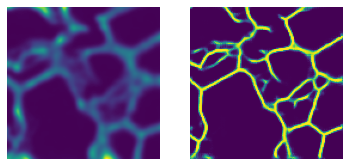

In [24]:
import matplotlib.pyplot as plt

plt.subplot(121)
plt.imshow(image[0][0])
plt.axis('off')

plt.subplot(122)
plt.imshow(norm)
plt.axis('off')

plt.show()

In [3]:
#######  V2 #############


import torch
import torch.nn as nn
import torch.nn.functional as F

from groupy.gconv.pytorch_gconv.splitgconv2d import P4ConvZ2, P4ConvP4
from groupy.gconv.pytorch_gconv import P4MConvZ2, P4MConvP4M
from groupy.gconv.pytorch_gconv.pooling import plane_group_spatial_max_pooling

class NNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(NNet, self).__init__()
        

        self.conv1 = P4MConvZ2(in_channels, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = P4MConvP4M(32, 32, kernel_size=3, stride=1, padding=1)

        self.conv3 = P4MConvP4M(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv4 = P4MConvP4M(64, 128, kernel_size=3, stride=1, padding=1)

        self.conv5 = P4MConvP4M(128, 64, kernel_size=3, padding=1)
        self.conv6 = P4MConvP4M(64, 32, kernel_size=3, padding=1)

#         self.conv3 = P4MConvP4M(48, 96, kernel_size=3, stride=1, padding=1)
#         self.conv4 = P4MConvP4M(96, 192, kernel_size=3, stride=1, padding=1)

#         self.conv5 = P4MConvP4M(192, 96, kernel_size=3, padding=1)
#         self.conv6 = P4MConvP4M(96, 48, kernel_size=3, padding=1)
        self.convt = nn.ConvTranspose2d(32*8, out_channels, kernel_size=2, stride=2, output_padding=0)


    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = plane_group_spatial_max_pooling(x, 2, 2)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        xs = x.size()
        x = x.view(xs[0], xs[1] * xs[2], xs[3], xs[4])
#         x = F.avg_pool2d(x, 2, 2)
        x = self.convt(x)

        return x

In [7]:
from skimage import restoration
from skimage.filters import threshold_otsu
import copy
import imageio
from PIL import Image


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

import numpy as np



# Define your transformation
transform = transforms.Compose([
    transforms.ToTensor()
])


model = NNet(1, 1)
model.load_state_dict(torch.load('/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/NNet_groupy_p4m_v2.pth'))

groups = ['climp', 'control', 'rtn']

for group in groups:
    for i in range(1, 17):
        try:
            imgpath = f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/{group}/er_mean_blur/{group}{i}_er_mean_blur.png'

            image = Image.open(imgpath)
            transform = transforms.Compose([
                transforms.ToTensor(),
            ])

            image = transform(image)
            image = image.unsqueeze(0)  # Add batch dimension

            # Forward pass through the model
            model.eval()
            with torch.no_grad():
                output = model(image)

            # Convert the output to probabilities by applying the sigmoid activation
            output_probs = torch.sigmoid(output)

            # Convert tensors to numpy arrays for visualization
            image_np = image.squeeze().numpy()
            output_probs_np = output_probs.cpu().squeeze().numpy()

            norm = (output_probs_np - output_probs_np.min()) / (output_probs_np.max() - output_probs_np.min())

            rb = restoration.rolling_ball(norm)
            subt = norm - rb

            thr = threshold_otsu(subt)

            subt2 = copy.deepcopy(subt)

            subt2[subt < thr] = 0.
            subt2[subt >= thr] = 255.

#             imageio.imsave(f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/{group}/nerdynet_v2/sted_{group}{i}_er_mean_pred.png', subt2)
            imageio.imsave(f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/{group}/blur_p4m_v2/sted_{group}{i}_er_mean_pred.png', subt2)
        except:
            pass

Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
